In [1]:
# import tree_comparison.tree_compare as tc
# from joblib import Memory
from itertools import combinations
import pandas as pd
import seaborn as sns
import numpy as np
from glob import glob
# from utils import *
import utils as u

import neuron_morphology.vis.morphovis as mv 
from neuron_morphology.swc_io import morphology_from_swc, read_swc
from neuron_morphology.morphology import Morphology
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("/data/LC_soma_shapes.csv", index_col="id")
df.head()


,soma,soma_offset,radii,volume,rsquared,primary_axis,soma_offset_magnitude
id,,,,,,,
N010-685222,[14720.6944 11631.7978 16186.722727],[ 0.42742857 -7.69371429 -4.57142857],[ 17.34029009 26.21208164 107.89902835],205430.069822,0.611328,[-0.89194859 -0.43279558 -0.13082697],8.959570
N038-685222,[14449.910692 9914.868864 10556.101253],[-2.3936 0.5984 -7.2 ],[17.74396404 24.5843088 67.40225392],123160.567106,0.743368,[-0.89232505 -0.36383261 -0.26717381],7.611005
N008-685222,[15115.202169 11593.030881 16119.537637],[-2.992 1.088 -6.90909091],[ 19.40753697 24.86107111 100.82514185],203773.501827,0.614664,[-0.9765063 -0.20017874 -0.07977423],7.607322
N009-685222,[15033.155651 11621.781787 16276.059435],[-1.7952 -5.6848 -2.8 ],[ 17.70722166 23.80767337 112.44292024],198558.326956,0.772748,[-0.91156984 -0.34482605 -0.22390942],6.586326
N026-685222,[15364.571216 11265.093714 10624.452406],[-6.64888889 -9.64088889 10.22222222],[18.17741415 37.52939469 52.21438961],149204.690701,0.692856,[0.95744477 0.26318416 0.11846353],15.545041


In [3]:

for col in ["radii", "primary_axis", "soma_offset", "soma"]:
    df[col] = df[col].str.replace(r"\[\s*|\s*\]", "", regex=True).str.split(r"\s+")
    # move column of lists to separate columns
    df = df.assign(
        **{f"{col}_{i}": df[col].apply(lambda x: float(x[i])) for i in range(3)}
    )


In [44]:
from collections import OrderedDict
def intersection_points(m, cutoff = 100):
    root = m.get_root()
    hits = OrderedDict()
    record = {}
    # hits[root["id"]] = root
    def visit(node):
        # c = m.get_compartment_for_node(node)
        # if c is None:
        #     return
        # if (cutoff > m.euclidean_distance(root, c[0]) and cutoff < m.euclidean_distance(root, c[1])):
            # hits[node["id"]] = c[0]
        record["stop"] = False
        if node["type"]==1:
            return
        if node["type"]==3:
            is_second_branch = len(m.get_children(node)) > 1
            if cutoff < m.euclidean_distance(root, node) or is_second_branch:
                hits[node["id"]] = node
                record["stop"] = True
        else:
            # not dendrite or soma
            record["stop"] = True
        return
    def cb(node_id):
        if record["stop"]:
            # stop traversal
            return []
        else:
            nested_ids = m.child_ids([node_id])
            children = [nid for nids in nested_ids for nid in nids]
            if len(children) > 1:
                record["branch_root"] = node_id
            return children

    m.breadth_first_traversal(visit, cb)
    return hits

def get_bipolarity(soma, stems, primary_axis, cos2_cutoff=0.5):
    val = 0.0
    aligned_avg = 0.0
    avg0 = np.array([0,0,0])
    avg1 = np.array([0,0,0])
    avg2 = np.array([0,0,0])
    # cos2_vals = []
    n = len(stems)
    primary_axis = np.array(primary_axis)
    primary_axis = primary_axis / np.linalg.norm(primary_axis)
    vecs = []
    for stem in stems.values():
        vec = np.array([float(stem[i]) for i in "xyz"]) - np.array(soma)
        vec = vec / np.linalg.norm(vec)
        vecs.append(vec.astype(float))

        avg0 = avg0 + (vec * np.sign(vec[0])/n)
        avg1 = avg1 + (vec * np.sign(vec[1])/n)
        avg2 = avg2 + (vec * np.sign(vec[2])/n)
        aligned = np.abs(np.dot(vec, primary_axis))
        aligned_avg += aligned/n
        if aligned**2 > cos2_cutoff:
            val += 1.0/n
    vectors = np.array(vecs)
    S = vectors.T @ vectors / len(vectors)
    eigenvalues, eigenvectors = np.linalg.eigh(S)
    avg, norm_avg = eigenvectors[:, 2], np.sqrt(eigenvalues[2])
    # avg_candidates = [avg0, avg1, avg2]
    # avg = max(avg_candidates, key=lambda x: np.linalg.norm(x))
    # norm_avg = np.linalg.norm(avg)
    # abs_cos = np.abs(np.dot(avg, primary_axis))/norm_avg
    abs_cos = np.abs(np.dot(avg, primary_axis))
    return val, aligned_avg, norm_avg, abs_cos

In [45]:
from tqdm import tqdm
names = ["aligned_bipolar_frac","aligned_bipolarity","abs_bipolarity", "cos_primary_axis"]
names_offset = [x+"_offset" for x in names]
df[names] = None
df[names_offset] = None
df["num_stems"] = None
# cos2_vals = []
# cos2_vals_offset = []
index = []
for swc in tqdm(glob("/scratch/LC-image-space/*/*.swc")[:]):
    id = swc.split("/")[-1][:11]
    if id not in df.index:
        # print(f"missing {id}")
        continue
    index.append(id)
    morph = morphology_from_swc(swc)
    # morph_soma = [morph.get_soma()[i] for i in "xyz"]
    # morph soma == spreadsheet soma

    r2 = float(df.loc[id, "radii_2"])
    r2 = 50
    stems = intersection_points(morph, cutoff=r2)
    df.loc[id, "num_stems"] = len(stems)

    soma = df.loc[id, [f"soma_{i}" for i in range(3)]].values
    primary_axis = df.loc[id, [f"primary_axis_{i}" for i in range(3)]].values
    df.loc[id, names] = get_bipolarity(soma, stems, primary_axis, cos2_cutoff=0.5)
    # cos2_vals.append(vals)

    offset_soma = soma + df.loc[id, [f"soma_offset_{i}" for i in range(3)]].values
    df.loc[id, names_offset] = get_bipolarity(offset_soma, stems, primary_axis, cos2_cutoff=0.5)
    # cos2_vals_offset.append(vals)


100%|██████████| 131/131 [09:00<00:00,  4.13s/it]


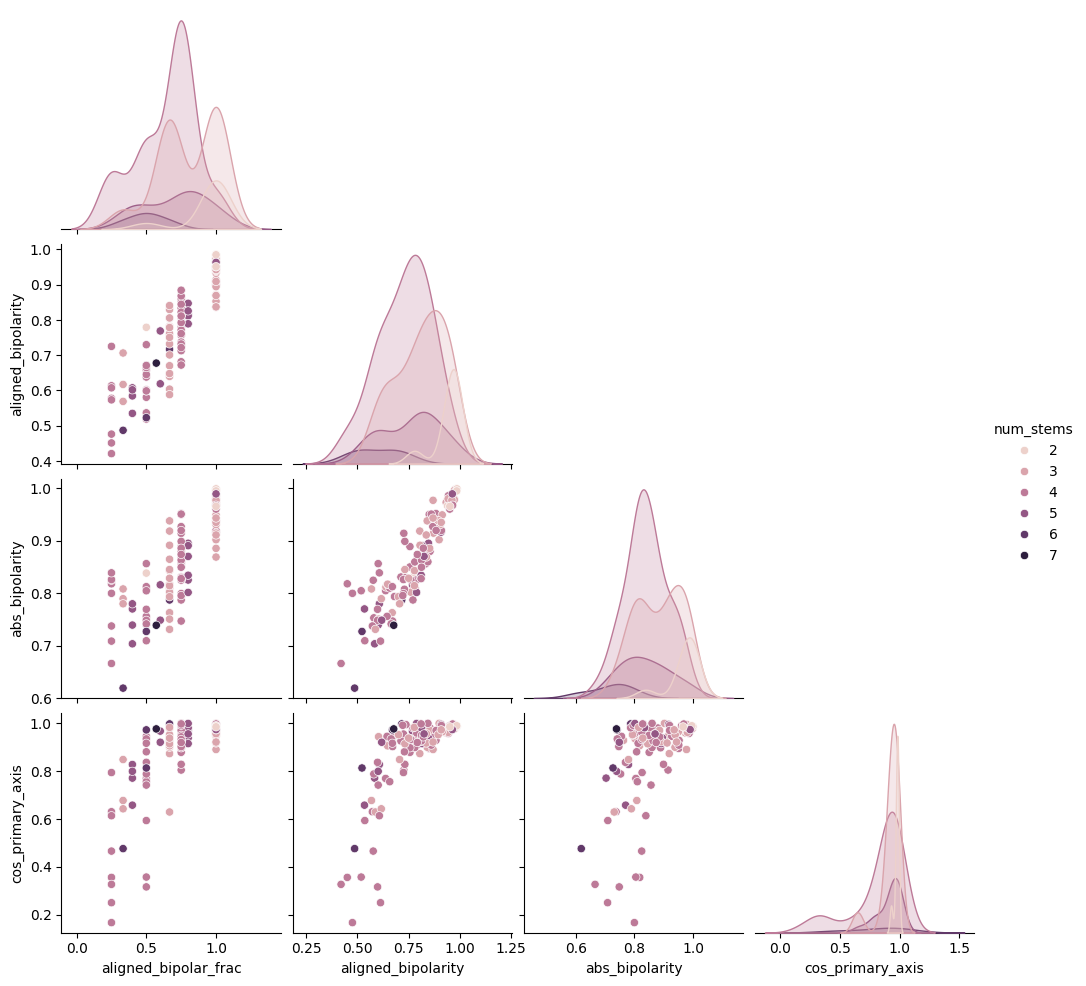

In [46]:

# df.loc[index, "mean_bipolarity"] = [np.mean(np.sqrt(np.array(x))) for x in cos2_vals]
# df.loc[index, "mean_bipolarity_offset"] = [np.mean(np.sqrt(np.array(x))) for x in cos2_vals_offset]
sns.pairplot(df, vars=names, corner=True, hue="num_stems")

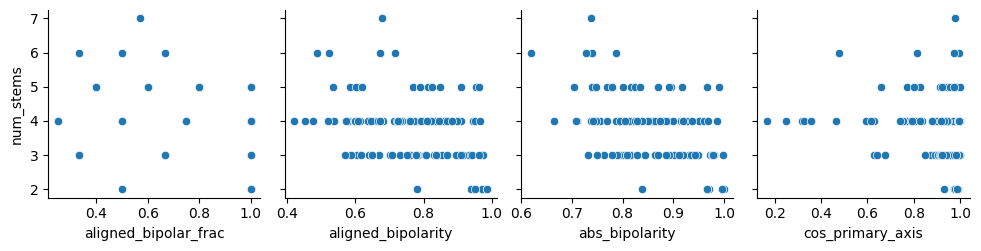

In [47]:

# df.loc[index, "mean_bipolarity"] = [np.mean(np.sqrt(np.array(x))) for x in cos2_vals]
# df.loc[index, "mean_bipolarity_offset"] = [np.mean(np.sqrt(np.array(x))) for x in cos2_vals_offset]
sns.pairplot(df, y_vars=["num_stems"], x_vars=names)

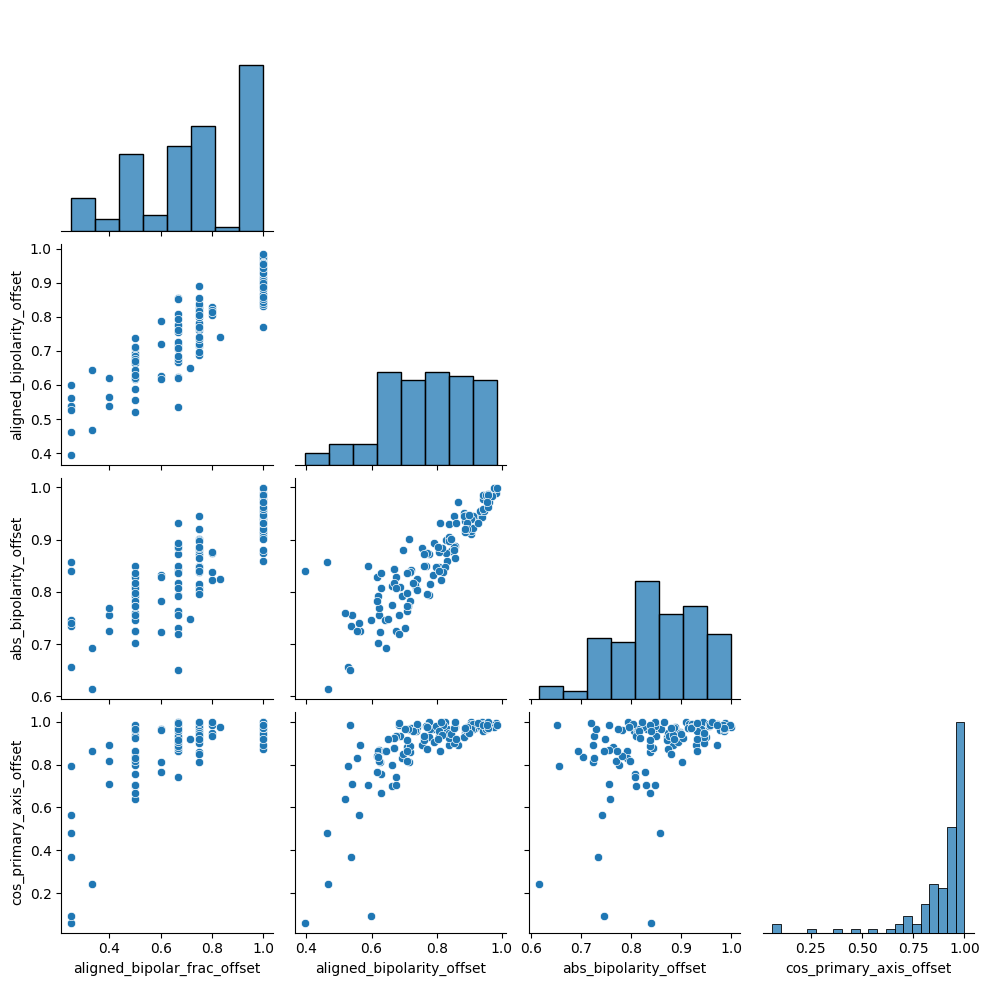

In [50]:

sns.pairplot(df[names_offset], corner=True)

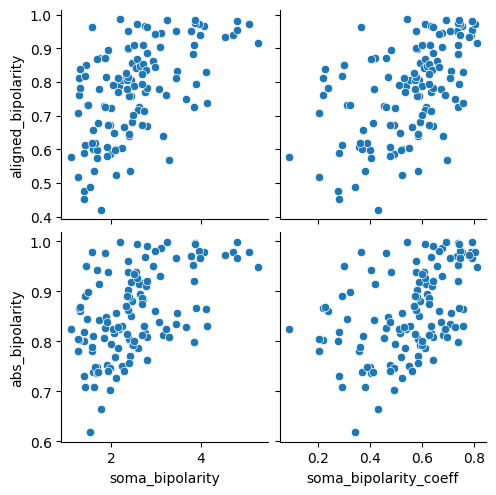

In [ ]:
r_mean = np.linalg.norm(df[["radii_0","radii_1"]], axis=1)
r_mean = np.sqrt(df["radii_0"] * df["radii_1"])
r_mean = df["radii_1"]
df["soma_bipolarity"] = df["radii_2"] / r_mean
df["soma_bipolarity_coeff"] = (df["radii_2"] - r_mean)/df["radii_2"]
# df["soma_bipolarity"] = df["radii_2"] / np.sqrt(df["radii_0"]*df["radii_1"])

sns.pairplot(df, y_vars=["aligned_bipolarity", "abs_bipolarity"], x_vars=["soma_bipolarity",])
# "soma_bipolarity_coeff"

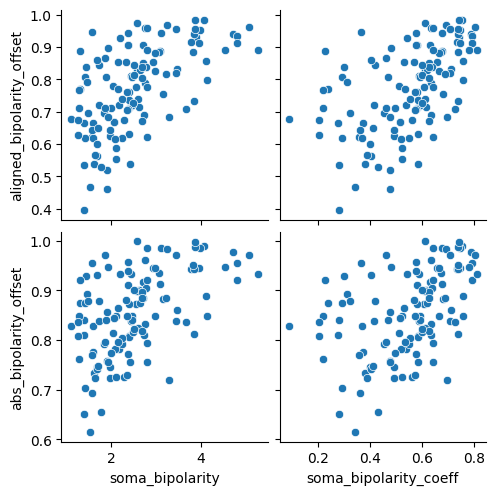

In [51]:

sns.pairplot(df, y_vars=["aligned_bipolarity_offset", "abs_bipolarity_offset"], x_vars=["soma_bipolarity","soma_bipolarity_coeff"])

In [48]:
df.to_csv("/scratch/lc_somas.csv")

## Locations (not CCF-aligned)

<AxesSubplot:xlabel='soma_0', ylabel='soma_1'>

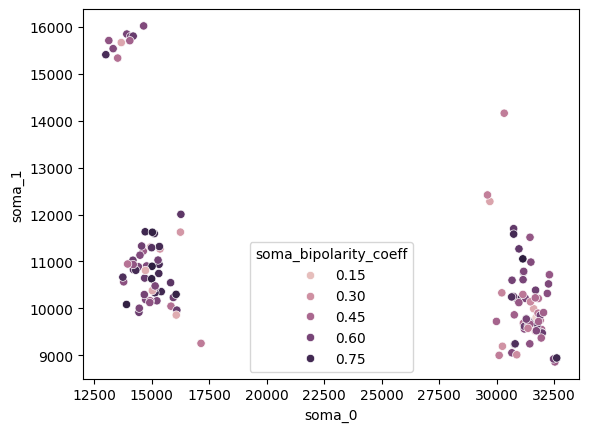

In [11]:
sns.scatterplot(df, x="soma_0", y="soma_1", hue="soma_bipolarity_coeff")

<AxesSubplot:xlabel='soma_0', ylabel='soma_1'>

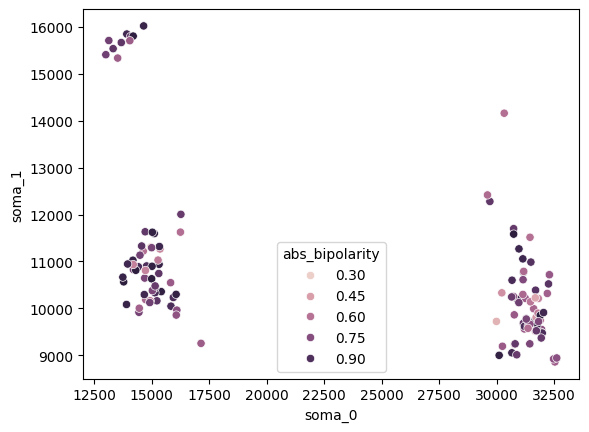

In [12]:
sns.scatterplot(df, x="soma_0", y="soma_1", hue="abs_bipolarity")